### Change of mind triggered ripple power

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)
warnings.simplefilter('ignore', category=UserWarning)

import matplotlib.pyplot as plt

In [3]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common import IntervalList
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.shijiegu.decodeHelpers import session2position_name

from spyglass.shijiegu.ripple_detection import loadRippleLFP_OneChannelPerElectrode
from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.shijiegu.load import load_session_name, load_position
from spyglass.shijiegu.helpers import mergeIntervals,interpolate_to_new_time
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd


[2026-01-11 18:12:24,907][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
def return_triggered_ripples(df, trialIDs, pos_info, time_type, session_mean, session_sd):
    filtered_lfps_subset_all = []

    for trialID in trialIDs:
        if time_type == "com": #change of mind
            t = df.loc[trialID].initial_time
        elif "reward" in time_type: #change of mind
            t = df.loc[trialID].timestamp_O
            
        t0, t1 = (t - 1, t + 3)
        t_axis = np.linspace(t0, t1, 4000)
        t_ind = np.logical_and(filtered_lfps_t_maze >= t0, filtered_lfps_t_maze <= t1)
        filtered_lfps_t_subset = filtered_lfps_t_maze[t_ind]
        filtered_lfps_subset = (np.mean(filtered_lfps_raw_maze[t_ind,:] ** 2, axis = 1) - session_mean) / session_sd

        pos_info_subset = select_subset_helper_pd(pos_info, (t0, t1+0.01))
        pos_info_subset = pos_info_subset.iloc[:len(filtered_lfps_subset)]
        assert len(pos_info_subset) == len(filtered_lfps_subset)
        low_speed_ind = np.array(pos_info_subset.head_speed) <= 4
        filtered_lfps_t_subset = filtered_lfps_t_subset[low_speed_ind]
        filtered_lfps_subset = filtered_lfps_subset[low_speed_ind]
        
        bins = np.digitize(filtered_lfps_t_subset, t_axis) - 1
        filtered_lfps_binned = np.zeros_like(t_axis)
        filtered_lfps_binned_count = np.zeros_like(t_axis)
        for ind in range(len(bins)):
            target_ind = bins[ind]
            filtered_lfps_binned[target_ind] += filtered_lfps_subset[ind]
            filtered_lfps_binned_count[target_ind] += 1
        filtered_lfps_binned = filtered_lfps_binned/filtered_lfps_binned_count
    
        filtered_lfps_subset_all.append(filtered_lfps_binned)
    filtered_lfps_subset_all = np.array(filtered_lfps_subset_all)
    
    t_axis = t_axis - t

    return filtered_lfps_subset_all, t_axis

In [5]:
nwb_file_name = "eliot20221021.nwb"

In [6]:
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
animal = nwb_file_name[:5]

In [7]:
session_interval, sleep_interval = load_session_name(nwb_copy_file_name)
print(session_interval)

['02_Seq2Session1', '04_Seq2Session2', '06_Seq2Session3', '08_Seq2Session4']


In [8]:
#df[df.rewardNum == 1]

In [9]:
com_all = []
reward_all = []

for session_name in session_interval:

    position_valid_times = (IntervalList & {'nwb_file_name': nwb_copy_file_name,
                                            'interval_list_name': session_name}).fetch1('valid_times')
    epoch_pos_name = session2position_name(nwb_copy_file_name, session_name)

    q = {"proportion": 0.1,
     "delta_t_minus":5, "delta_t_plus":5,
     "max_flag":1}

    q["nwb_file_name"] = nwb_copy_file_name
    q["epoch"] = session_name[:2]
    df = ChangeofMind().fetch1_dataframe(q)         # trials with long theta

    df_com = df[df.change_of_mind]
    df_nonreward = df[df.rewardNum == 1]

    #filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd = loadRippleLFP_OneChannelPerElectrode(
    #    nwb_copy_file_name,session_name,position_valid_times,'artifact removed filtered data',1)
    

    (filtered_lfps_raw, filtered_lfps_t,
     _2, _3) = loadRippleLFP_OneChannelPerElectrode(
         nwb_copy_file_name,
         session_name,position_valid_times,'filtered data',1)

    position_info = load_position(nwb_copy_file_name,epoch_pos_name)
    position_info_upsample = interpolate_to_new_time(position_info, filtered_lfps_t)

    t0, t1 = (df.loc[1].timestamp_O, df.loc[80].timestamp_O)

    t_ind = np.logical_and(filtered_lfps_t >= t0, filtered_lfps_t <= t1)

    # get session threshold
    filtered_lfps_raw_maze = filtered_lfps_raw[t_ind]
    filtered_lfps_t_maze = filtered_lfps_t[t_ind]
    session_mean = np.mean(np.mean(filtered_lfps_raw_maze ** 2, axis = 1))
    session_sd = np.std(np.mean(filtered_lfps_raw_maze ** 2, axis = 1))

    lfp_com, t_axis_com = return_triggered_ripples(df, df_com.index[df_com.index < 80], position_info_upsample,
                                                            "com", session_mean, session_sd)

    lfp_reward, t_axis_reward = return_triggered_ripples(df, df_nonreward.index[df_nonreward.index < 80],position_info_upsample,
                                                            "reward", session_mean, session_sd)

    com_all.append(lfp_com)
    reward_all.append(lfp_reward)

com_all = np.vstack(com_all)
reward_all = np.vstack(reward_all)

[2026-01-11 18:12:38,631][WARNING]: Skipped checksum for file with hash: 626d7420-9063-346e-2144-88b98cf08637, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_WUIWB998PT.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:12:55,717][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,724][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,731][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,735][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:13:07,702][WARNING]: Skipped checksum for file with hash: e44d0a0c-2274-73bd-441e-61bcd4107fc3, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_GUR45AHIGJ.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:13:21,587][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,598][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,609][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,616][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:31,208][WARNING]: Skipped checksum for file with hash: af46516c-7d03-7e75-cf5e-70a2e1064c76, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_15ETSO398L.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:13:43,924][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,934][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,945][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,952][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:52,925][WARNING]: Skipped checksum for file with hash: cb6affd0-a7db-d78a-f991-971eb73dbe89, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_4I62DJC829.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:14:06,353][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,364][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,374][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,380][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb


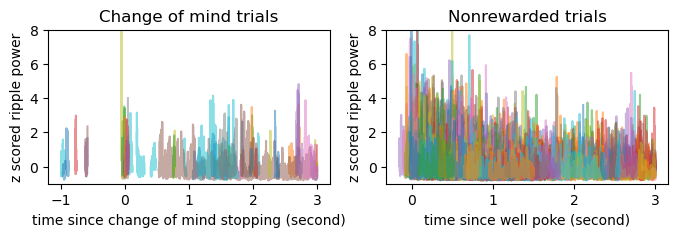

In [10]:
fig, axes = plt.subplots(1,2,figsize = (8, 2),sharey = True)

ax = axes[0]
for lfp in com_all:
    ax.plot(t_axis_com, lfp, alpha = 0.5)
mean = np.mean(com_all,axis = 0)
#std = np.std(com_all,axis = 0)

#ax.plot(t_axis_com, mean, color = 'k', linewidth = 2, label = "mean trace")
#ax.fill_between(t_axis_com, mean - std, mean + std, color = 'magenta', alpha = 0.5)
ax.set_title("Change of mind trials")
ax.set_xlabel("time since change of mind stopping (second)")
ax.set_ylabel("z scored ripple power")
#ax.legend()

ax1 = axes[1]
for lfp in reward_all:
    ax1.plot(t_axis_reward, lfp, alpha = 0.5)
mean = np.mean(reward_all,axis = 0)
#std = np.std(reward_all,axis = 0)

#ax1.plot(t_axis_reward, mean, color = 'k', linewidth = 2, label = "mean trace")
#ax1.fill_between(t_axis_reward, mean - std, mean + std, color = 'magenta', alpha = 0.5)
ax1.set_title("Nonrewarded trials")
ax1.set_xlabel("time since well poke (second)")
ax1.set_ylabel("z scored ripple power")
ax1.tick_params(labelleft=True)
ax1.set_ylim([-1,8])
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2/triggered_ripple_power_{animal}.pdf',dpi=300,bbox_inches='tight')